# grahspj: Fairall 9 From the VizieR SED Tool

This notebook queries broadband photometry for `Fairall 9` from the CDS VizieR SED service, maps a supported subset of filters into `grahspj`, and fits the resulting SED.

Workflow:
- query the VizieR SED tool by object name
- keep only filters with transmission curves available to `grahspj`
- build a manual `FitConfig`
- run a MAP fit
- inspect the fitted summary and SED plot


## Prerequisites

This notebook assumes:
- you are running from the `notebooks/` directory of this repository
- `grahspj` dependencies are installed
- internet access is available for the VizieR SED query
- a valid DSPS SSP file is available

By default the notebook looks for `../jaxqsofit/tempdata.h5` as a sibling checkout. Adjust that path if your SSP file lives elsewhere.

Notes:
- the VizieR SED service returns many heterogeneous measurements; this notebook keeps only a conservative subset of filters that already have known transmission curves
- when multiple measurements map onto the same filter, the notebook keeps the entry with the smallest fractional flux uncertainty
- the redshift is fixed to a literature value for Fairall 9 in this example rather than fit as a photo-z


In [11]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table

project_root = Path.cwd().resolve().parent
src_root = project_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from grahspj.config import AGNConfig, FilterSet, FitConfig, GalaxyConfig, InferenceConfig, LikelihoodConfig, Observation, PhotometryData
from grahspj.core import GRAHSPJ
from grahspj.mplstyle import style_path
from utils import query_vizier_sed

plt.style.use(style_path())


In [12]:
target_name = "Fairall 9"
target_redshift = 0.04587
search_radius_arcsec = 3.0

phot_rows, sed_table, vizier_url = query_vizier_sed(
    target_name,
    radius=search_radius_arcsec,
    host=("vizier.cfa.harvard.edu", 443, True),
    fallback_hosts=[("vizier.u-strasbg.fr", 80, False)],
    timeout=120,
)

print("Queried URL:", vizier_url)
print("Rows returned:", len(sed_table))
print("Columns:", sed_table.colnames)
sed_table[:5]


Queried URL: https://vizier.cfa.harvard.edu/viz-bin/sed?-c=Fairall+9&-c.rs=3.000000
Rows returned: 432
Columns: ['_RAJ2000', '_DEJ2000', '_tabname', '_ID', '_time', '_etime', 'sed_freq', 'sed_flux', 'sed_eflux', 'sed_filter']


_RAJ2000,_DEJ2000,_tabname,_ID,_time,_etime,sed_freq,sed_flux,sed_eflux,sed_filter
deg,deg,,,d,,GHz,Jy,Jy,
float64,float64,str32,str128,float64,float64,float64,float32,float32,str32
20.94125417,-58.80592222,I/275/ac2002,recno=3921191,--,0.0,713280,0.0307,--,HIP:BT
20.94063530,-58.80578170,I/297/out,"NOMAD1===0311-0008670&-c=020.9406353 -58.8057817,eq=J2000&-c.rs=0.004",--,0.0,181750,0.0151,--,2MASS:H
20.94063530,-58.80578170,I/297/out,"NOMAD1===0311-0008670&-c=020.9406353 -58.8057817,eq=J2000&-c.rs=0.004",--,0.0,241960,0.00944,--,2MASS:J
20.94063100,-58.80573200,I/305/out,"GSC2.3===S1C7000044&-c=020.940631 -58.805732,eq=J2000&-c.rs=0.004",--,--,382540,0.12,0.032,POSS-II:i
20.94063100,-58.80573200,I/305/out,"GSC2.3===S1C7000044&-c=020.940631 -58.805732,eq=J2000&-c.rs=0.004",--,--,468430,0.263,0.032,POSS-II:F


In [13]:
print("Supported photometric points kept for fitting:")
for row in phot_rows:
    print(row)


Supported photometric points kept for fitting:
{'vizier_filter': 'WISE:W4', 'grahsp_filter': 'W4', 'speclite_name': 'wise2010-W4', 'psf_fwhm_arcsec': 11.99, 'freq_ghz': 13571.0, 'flux_mjy': 463.99998664855957, 'err_mjy': 7.000000216066837, 'frac_err': 0.015086207796313453, 'catalog': 'II/311/wise'}
{'vizier_filter': 'WISE:W3', 'grahsp_filter': 'W3', 'speclite_name': 'wise2010-W3', 'psf_fwhm_arcsec': 7.36, 'freq_ghz': 25934.0, 'flux_mjy': 241.99999868869781, 'err_mjy': 4.000000189989805, 'frac_err': 0.016528926494480258, 'catalog': 'I/353/gsc242'}
{'vizier_filter': 'WISE:W2', 'grahsp_filter': 'W2', 'speclite_name': 'wise2010-W2', 'psf_fwhm_arcsec': 6.84, 'freq_ghz': 65172.0, 'flux_mjy': 104.99999672174454, 'err_mjy': 1.0000000474974513, 'frac_err': 0.00952381027351366, 'catalog': 'II/365/catwise'}
{'vizier_filter': 'WISE:W1', 'grahsp_filter': 'W1', 'speclite_name': 'wise2010-W1', 'psf_fwhm_arcsec': 6.08, 'freq_ghz': 89490.0, 'flux_mjy': 73.39999824762344, 'err_mjy': 0.7999999797903001, 

In [14]:
dsps_ssp_fn = project_root.parent / "jaxqsofit" / "tempdata.h5"
assert dsps_ssp_fn.is_file(), f"DSPS SSP file not found: {dsps_ssp_fn}"

cfg = FitConfig(
    observation=Observation(
        object_id=target_name,
        redshift=target_redshift,
        fit_redshift=False,
    ),
    photometry=PhotometryData(
        filter_names=[row["grahsp_filter"] for row in phot_rows],
        fluxes=[row["flux_mjy"] for row in phot_rows],
        errors=[row["err_mjy"] for row in phot_rows],
        is_upper_limit=[False] * len(phot_rows),
    ),
    filters=FilterSet(
        speclite_names={row["grahsp_filter"]: row["speclite_name"] for row in phot_rows},
        use_grahsp_database=False,
    ),
    galaxy=GalaxyConfig(dsps_ssp_fn=str(dsps_ssp_fn)),
    agn=AGNConfig(agn_type=1),
    likelihood=LikelihoodConfig(),
    inference=InferenceConfig(map_steps=400, learning_rate=5e-3),
    prior_config={
        "log_stellar_mass": {"loc": 10.5, "scale": 1.0},
        "fracAGN_5100": {"loc": 0.8, "scale": 0.15},
        "ebv_gal": {"scale": 0.15},
        "ebv_agn": {"scale": 0.15},
    },
)

print("Configured filters:", cfg.photometry.filter_names)
print("Configured redshift:", cfg.observation.redshift)


Configured filters: ['W4', 'W3', 'W2', 'W1', 'Ks_2mass', 'H_2mass', 'J_2mass', 'i_sdss', 'r_sdss', 'V_johnson', 'g_sdss', 'B_johnson', 'NUV_galex', 'FUV_galex']
Configured redshift: 0.04587


In [15]:
cfg.photometry.psf_fwhm_arcsec = [row["psf_fwhm_arcsec"] for row in phot_rows]
cfg.likelihood.use_host_capture_model = True

# Override default psf_fwhm_arcsec with values if you need to
# cfg.photometry.aperture_diameter_arcsec = [...]


### Host-Capture Model

When `use_host_capture_model=True`, the fit no longer assumes that every band contains the same fraction of host-galaxy light. Instead, the observed photometry is modeled as

$$F_{\mathrm{model},i} = F_{\mathrm{AGN},i} + \eta_i F_{\mathrm{host},i},$$

where $\eta_i$ is a band-dependent host-capture fraction. The AGN is treated as unresolved, while the host contribution is allowed to increase with the effective spatial scale of the measurement.

The effective spatial scale is taken from `aperture_diameter_arcsec` when provided, otherwise from `psf_fwhm_arcsec`. The model fits a shared monotonic curve

$$\eta_i = \sigma\left[s\,\left(\log R_i - \log R_0\right)\right],$$

with fitted turnover scale $R_0$ and slope $s$. Small-PSF or profile-fit measurements therefore capture less host light, while larger apertures or lower-resolution bands asymptotically approach the full host flux.

The likelihood is otherwise unchanged: the corrected model fluxes are compared to the photometry with the same Student-t likelihood, observational errors, intrinsic scatter, systematics term, and AGN variability term used elsewhere in `grahspj`.


In [16]:
fitter = GRAHSPJ(cfg)
fit_result = fitter.fit(
    fit_method="optax+nuts",
    prior_config=cfg.prior_config,
    dsps_ssp_fn=cfg.galaxy.dsps_ssp_fn,
    optax_steps=cfg.inference.map_steps,
    optax_lr=cfg.inference.learning_rate,
    plot_fig=False,
    save_fig=False,
    save_result=False,
    progress_bar=True,
)


sample: 100%|██████████| 1500/1500 [21:10<00:00,  1.18it/s, 255 steps of size 1.55e-02. acc. prob=0.84]


/Users/colinburke/research/grahspj/src/grahspj/plotting.py:218: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


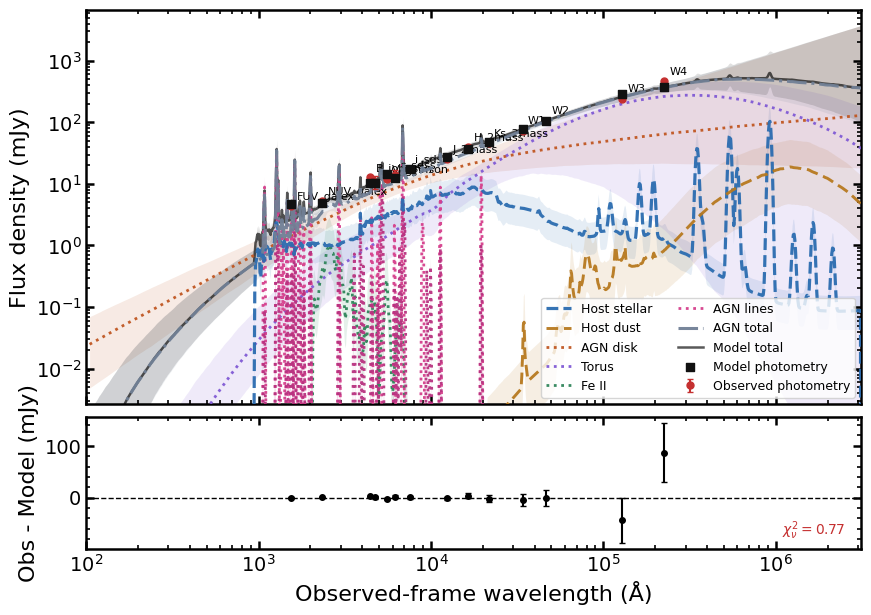

In [17]:
pred = fitter.predict()
fig = fitter.plot_sed(show=True)


In [18]:
model_flux = np.asarray(pred["pred_fluxes"][0], dtype=float)
host_flux = np.asarray(pred["host_fluxes"][0], dtype=float)
dust_flux = np.asarray(pred["dust_fluxes"][0], dtype=float)
agn_flux = np.asarray(pred["agn_fluxes"][0], dtype=float)
phot_wave = np.asarray([flt.effective_wavelength for flt in fitter.context.filters], dtype=float)

print("filter, eff_wave_A, obs_mJy, err_mJy, model_mJy, host_mJy, dust_mJy, agn_mJy")
for name, wave, obs, err, model, host, dust, agn in zip(
    cfg.photometry.filter_names,
    phot_wave,
    cfg.photometry.fluxes,
    cfg.photometry.errors,
    model_flux,
    host_flux,
    dust_flux,
    agn_flux,
):
    print((name, wave, obs, err, model, host, dust, agn))


filter, eff_wave_A, obs_mJy, err_mJy, model_mJy, host_mJy, dust_mJy, agn_mJy
('W4', np.float64(223752.7751557955), 463.99998664855957, 7.000000216066837, np.float64(312.35980993878854), np.float64(0.5621143835011433), np.float64(1.279061178038588), np.float64(310.5186343772489))
('W3', np.float64(128103.3789599012), 241.99999868869781, 4.000000189989805, np.float64(280.5713436390799), np.float64(0.5266208879593609), np.float64(0.3367360670748101), np.float64(279.70798668404575))
('W2', np.float64(46520.07577118702), 104.99999672174454, 1.0000000474974513, np.float64(108.28023203895538), np.float64(0.5322729304437284), np.float64(0.006499221435521396), np.float64(107.74145988707613))
('W1', np.float64(34002.540444816936), 73.39999824762344, 0.7999999797903001, np.float64(76.68759682229656), np.float64(0.7103064567494121), np.float64(0.006058884427837673), np.float64(75.97123148111932))
('Ks_2mass', np.float64(21656.2428602493), 45.80000042915344, 1.500000013038516, np.float64(45.5446255

## Notes

- If the VizieR SED service returns additional supported filters for your environment, they will be picked up automatically by the mapping cell.
- To fit redshift as well, set `cfg.observation.fit_redshift = True` and provide `cfg.observation.redshift_err`.
- For a fuller posterior exploration, switch the fit call to `fit_method="optax+nuts"` and increase the warmup/sample counts.
